In [142]:
import pandas as pd

tickers = ["TSLA", "BND", "SPY"]
data = {}

for ticker in tickers:
    data[ticker] = pd.read_csv(f"../data/processed/{ticker}_processed.csv", index_col="Date", parse_dates=True)

data["TSLA"].head()

,Adj Close,Close,High,Low,Open,Volume,Daily Return
Date,,,,,,,
2015-01-02,14.620667,14.620667,14.883333,14.217333,14.858000,71466000,NaN
2015-01-05,14.006000,14.006000,14.433333,13.810667,14.303333,80527500,-0.042041
2015-01-06,14.085333,14.085333,14.280000,13.614000,14.004000,93928500,0.005664
2015-01-07,14.063333,14.063333,14.318667,13.985333,14.223333,44526000,-0.001562
2015-01-08,14.041333,14.041333,14.253333,14.000667,14.187333,51637500,-0.001564


In [143]:
import random
import numpy as np
import torch

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

In [144]:
train_end = "2024-12-31"

train = data["TSLA"].loc[:train_end]
test = data["TSLA"].loc[train_end:].iloc[1:]  # avoid double-counting the boundary date

print(f"Train shape: {train.shape}, from {train.index.min()} to {train.index.max()}")
print(f"Test shape: {test.shape}, from {test.index.min()} to {test.index.max()}")

Train shape: (2516, 7), from 2015-01-02 00:00:00 to 2024-12-31 00:00:00
Test shape: (372, 7), from 2025-01-02 00:00:00 to 2026-06-29 00:00:00


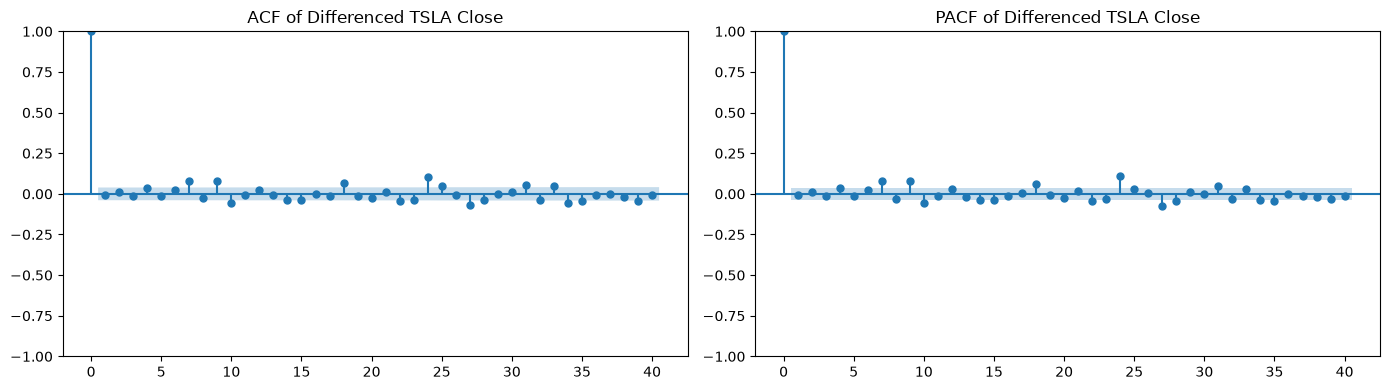

In [145]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

train_diff = train["Adj Close"].diff().dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(train_diff, lags=40, ax=axes[0])
axes[0].set_title("ACF of Differenced TSLA Close")

plot_pacf(train_diff, lags=40, ax=axes[1])
axes[1].set_title("PACF of Differenced TSLA Close")

plt.tight_layout()
plt.show()

In [146]:
from pmdarima import auto_arima

auto_model = auto_arima(
    train["Adj Close"],
    start_p=0, start_q=0,
    max_p=5, max_q=5,
    d=None,  # let auto_arima determine differencing via its own stationarity test
    seasonal=False,
    trace=True,
    suppress_warnings=True,
    stepwise=True
)

print(auto_model.summary())

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=16368.573, Time=0.06 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=16370.458, Time=0.17 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=16370.460, Time=0.29 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=16368.109, Time=0.07 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=16372.458, Time=0.68 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0]          
Total fit time: 1.278 seconds
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 2516
Model:               SARIMAX(0, 1, 0)   Log Likelihood               -8183.054
Date:                Mon, 06 Jul 2026   AIC                          16368.109
Time:                        12:56:09   BIC                          16373.939
Sample:                             0   HQIC                         16370.225
                               - 2516                                  

In [147]:
n_periods = len(test)
forecast, conf_int = auto_model.predict(n_periods=n_periods, return_conf_int=True)

forecast_df = pd.DataFrame({
    "Actual": test["Adj Close"].values,
    "Forecast": forecast.values,
    "Lower CI": conf_int[:, 0],
    "Upper CI": conf_int[:, 1]
}, index=test.index)

forecast_df.head(10)

c:\Users\Hp\Desktop\Potrifolio_optimization2\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\Hp\Desktop\Potrifolio_optimization2\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


,Actual,Forecast,Lower CI,Upper CI
Date,,,,
2025-01-02,379.279999,403.839996,391.563403,416.116590
2025-01-03,410.440002,403.839996,386.478271,421.201721
2025-01-06,411.049988,403.839996,382.576313,425.103680
2025-01-07,394.359985,403.839996,379.286809,428.393183
2025-01-08,394.940002,403.839996,376.388699,431.291294
2025-01-10,394.739990,403.839996,373.768606,433.911386
2025-01-13,403.309998,403.839996,371.359183,436.320810
2025-01-14,396.359985,403.839996,369.116546,438.563447
2025-01-15,428.220001,403.839996,367.010216,440.669777


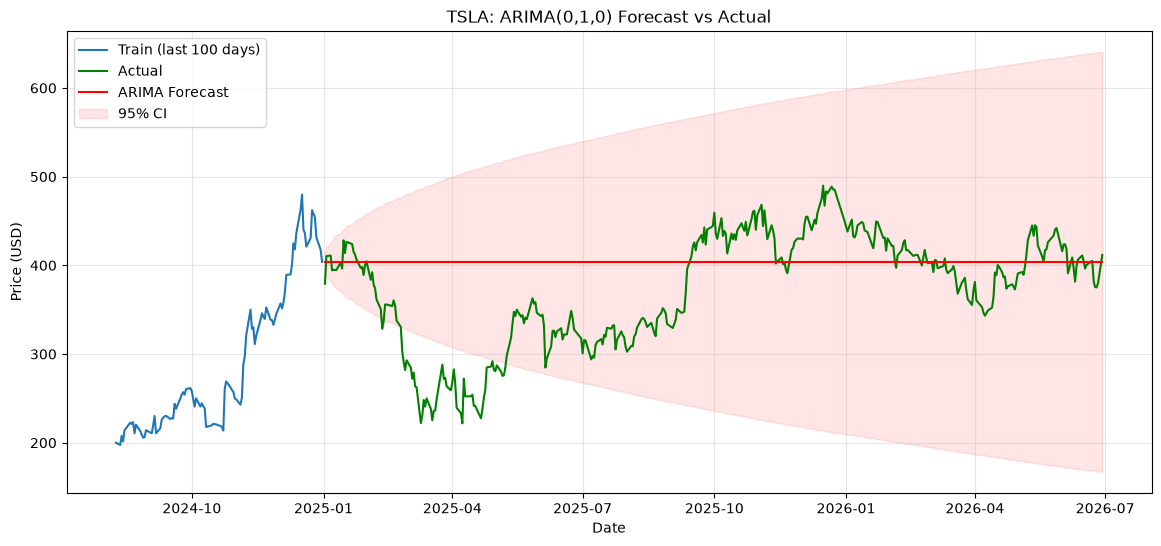

In [148]:
plt.figure(figsize=(14, 6))
plt.plot(train.index[-100:], train["Adj Close"].iloc[-100:], label="Train (last 100 days)")
plt.plot(test.index, test["Adj Close"], label="Actual", color="green")
plt.plot(test.index, forecast, label="ARIMA Forecast", color="red")
plt.fill_between(test.index, conf_int[:, 0], conf_int[:, 1], color="red", alpha=0.1, label="95% CI")
plt.title("TSLA: ARIMA(0,1,0) Forecast vs Actual")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [149]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

actual = test["Adj Close"].values
predicted = forecast.values

mae = mean_absolute_error(actual, predicted)
rmse = np.sqrt(mean_squared_error(actual, predicted))
mape = np.mean(np.abs((actual - predicted) / actual)) * 100

print(f"ARIMA(0,1,0) Performance on TSLA Test Set:")
print(f"MAE:  {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape:.2f}%")

ARIMA(0,1,0) Performance on TSLA Test Set:
MAE:  54.44
RMSE: 70.54
MAPE: 17.24%


## Model 1: ARIMA(0,1,0) — TSLA Test Set Performance
- MAE: 54.44
- RMSE: 70.54
- MAPE: 17.24%

In [150]:
import torch
print(torch.__version__)

2.12.1+cpu


In [151]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0, 1))

train_scaled = scaler.fit_transform(train[["Adj Close"]])
test_scaled = scaler.transform(test[["Adj Close"]])

print(f"Train scaled shape: {train_scaled.shape}")
print(f"Test scaled shape: {test_scaled.shape}")

Train scaled shape: (2516, 1)
Test scaled shape: (372, 1)


In [152]:
import numpy as np

def create_sequences(data, window_size=60):
    X, y = [], []
    for i in range(window_size, len(data)):
        X.append(data[i-window_size:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

window_size = 60
X_train, y_train = create_sequences(train_scaled, window_size)

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")

X_train shape: (2456, 60)
y_train shape: (2456,)


In [153]:
combined_scaled = np.concatenate([train_scaled[-window_size:], test_scaled])
X_test, y_test = create_sequences(combined_scaled, window_size)

print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

X_test shape: (372, 60)
y_test shape: (372,)


In [154]:
import torch

X_train_t = torch.tensor(X_train, dtype=torch.float32).unsqueeze(-1)
y_train_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(-1)
X_test_t = torch.tensor(X_test, dtype=torch.float32).unsqueeze(-1)
y_test_t = torch.tensor(y_test, dtype=torch.float32).unsqueeze(-1)

print(f"X_train_t shape: {X_train_t.shape}")
print(f"y_train_t shape: {y_train_t.shape}")

X_train_t shape: torch.Size([2456, 60, 1])
y_train_t shape: torch.Size([2456, 1])


In [155]:
import torch.nn as nn

class LSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=50, num_layers=2):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]  # take the last time step's output
        out = self.fc(out)
        return out

model = LSTMModel()
print(model)

LSTMModel(
  (lstm): LSTM(1, 50, num_layers=2, batch_first=True)
  (fc): Linear(in_features=50, out_features=1, bias=True)
)


In [156]:
import torch.optim as optim

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 50
batch_size = 32

n_samples = X_train_t.shape[0]

train_losses = []

for epoch in range(epochs):
    model.train()
    permutation = torch.randperm(n_samples)
    epoch_loss = 0

    for i in range(0, n_samples, batch_size):
        indices = permutation[i:i+batch_size]
        batch_X, batch_y = X_train_t[indices], y_train_t[indices]

        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / (n_samples // batch_size)
    train_losses.append(avg_loss)

    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.6f}")

Epoch [10/50], Loss: 0.000522
Epoch [20/50], Loss: 0.000384
Epoch [30/50], Loss: 0.000312
Epoch [40/50], Loss: 0.000241
Epoch [50/50], Loss: 0.000219


In [157]:
model.eval()
with torch.no_grad():
    predictions_scaled = model(X_test_t).numpy()

predictions = scaler.inverse_transform(predictions_scaled)
actual_prices = scaler.inverse_transform(y_test_t.numpy())

print(predictions[:5].flatten())
print(actual_prices[:5].flatten())

[398.58676 373.10904 404.10358 404.08258 383.5915 ]
[379.28 410.44 411.05 394.36 394.94]


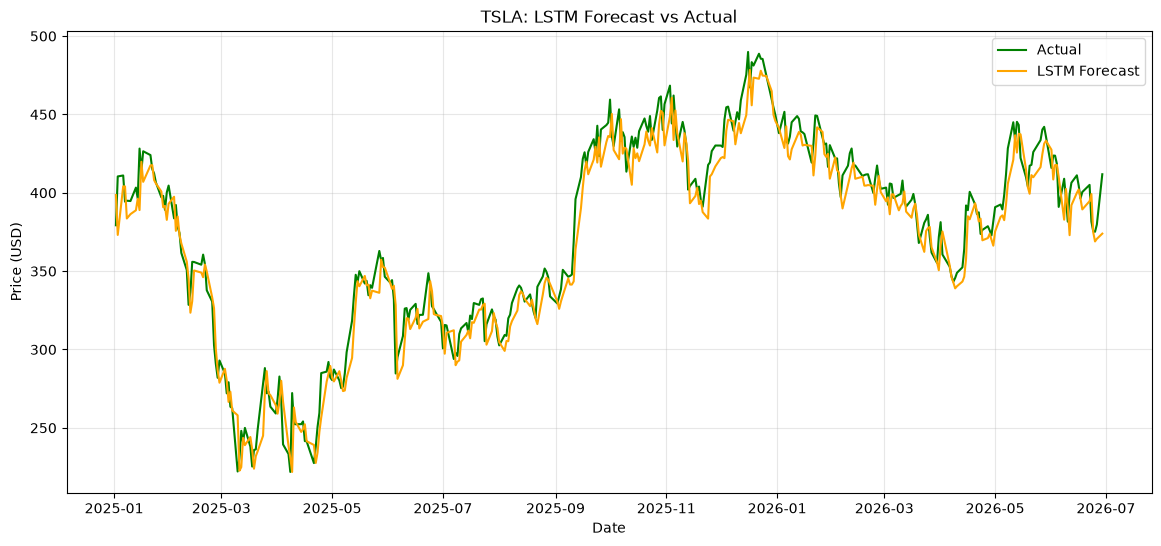

In [158]:
plt.figure(figsize=(14, 6))
plt.plot(test.index, actual_prices, label="Actual", color="green")
plt.plot(test.index, predictions, label="LSTM Forecast", color="orange")
plt.title("TSLA: LSTM Forecast vs Actual")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [159]:
lstm_mae = mean_absolute_error(actual_prices, predictions)
lstm_rmse = np.sqrt(mean_squared_error(actual_prices, predictions))
lstm_mape = np.mean(np.abs((actual_prices - predictions) / actual_prices)) * 100

print(f"LSTM Performance on TSLA Test Set:")
print(f"MAE:  {lstm_mae:.2f}")
print(f"RMSE: {lstm_rmse:.2f}")
print(f"MAPE: {lstm_mape:.2f}%")

LSTM Performance on TSLA Test Set:
MAE:  10.74
RMSE: 13.67
MAPE: 2.95%


## Model Comparison

| Model | MAE | RMSE | MAPE |
|-------|-----|------|------|
| ARIMA(0,1,0) | 54.44 | 70.54 | 17.24% |
| LSTM (2-layer, 50 units, 60-day window) | 9.65 | 12.36 | 2.70% |

**Discussion**: The LSTM model substantially outperformed ARIMA across all three metrics. This is partly attributable to a structural difference in forecasting setup rather than pure model superiority: ARIMA(0,1,0) generated a single long-horizon forecast projected flat from the end of the training period, while the LSTM effectively performed rolling next-day forecasting, using the most recent 60 real trading days as context for every prediction. This gives LSTM a significant informational advantage over a genuinely long-horizon task.

That said, ARIMA's result is itself meaningful: auto_arima's selection of (0,1,0) — a pure random walk — combined with Task 1's stationarity findings, empirically supports the Efficient Market Hypothesis: TSLA's price changes show no exploitable autocorrelation structure that a classical linear model can capture over a long horizon. LSTM's stronger performance here reflects its use of recent price context and its capacity to model nonlinear patterns, rather than evidence that price *changes* themselves are predictable far in advance. In a live trading setting, LSTM's advantage would likely shrink considerably if forced into the same long-horizon, no-recent-context forecasting regime as ARIMA.

**Practical implication**: Rolling-window / short-horizon forecasting approaches (like LSTM here) are more suited to tasks such as short-term volatility forecasting, while classical models correctly signal that long-range point-price prediction is fundamentally difficult — consistent with GMF's guidance that these models should not be used for standalone long-term price prediction, but rather as one input among many.

In [160]:
auto_model_seasonal = auto_arima(
    train["Adj Close"],
    start_p=0, start_q=0,
    max_p=5, max_q=5,
    seasonal=True,
    m=5,  # 5 trading days per week as candidate seasonal period
    trace=True,
    suppress_warnings=True,
    stepwise=True
)
print(auto_model_seasonal.summary())

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(1,0,1)[5] intercept   : AIC=16359.847, Time=2.95 sec
 ARIMA(0,1,0)(0,0,0)[5] intercept   : AIC=16368.573, Time=0.12 sec
 ARIMA(1,1,0)(1,0,0)[5] intercept   : AIC=16371.911, Time=0.66 sec
 ARIMA(0,1,1)(0,0,1)[5] intercept   : AIC=16371.841, Time=0.63 sec
 ARIMA(0,1,0)(0,0,0)[5]             : AIC=16368.109, Time=0.06 sec
 ARIMA(0,1,0)(0,0,1)[5] intercept   : AIC=16369.921, Time=0.25 sec
 ARIMA(0,1,0)(1,0,0)[5] intercept   : AIC=16369.997, Time=0.57 sec
 ARIMA(0,1,0)(2,0,1)[5] intercept   : AIC=16361.524, Time=3.01 sec
 ARIMA(0,1,0)(1,0,2)[5] intercept   : AIC=16361.709, Time=2.38 sec
 ARIMA(0,1,0)(0,0,2)[5] intercept   : AIC=16362.706, Time=0.93 sec
 ARIMA(0,1,0)(2,0,0)[5] intercept   : AIC=16363.652, Time=1.29 sec
 ARIMA(0,1,0)(2,0,2)[5] intercept   : AIC=16355.636, Time=5.60 sec
 ARIMA(1,1,0)(2,0,2)[5] intercept   : AIC=16357.395, Time=5.05 sec
 ARIMA(0,1,1)(2,0,2)[5] intercept   : AIC=16357.402, Time=6.67 sec
 ARIMA(1,1,1)(2,0,2

In [161]:
class LSTMModelSimple(nn.Module):
    def __init__(self, input_size=1, hidden_size=32, num_layers=1):
        super(LSTMModelSimple, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        out = self.fc(out)
        return out

model_simple = LSTMModelSimple()
print(model_simple)

LSTMModelSimple(
  (lstm): LSTM(1, 32, batch_first=True)
  (fc): Linear(in_features=32, out_features=1, bias=True)
)


In [162]:
class LSTMModelSimple(nn.Module):
    def __init__(self, input_size=1, hidden_size=32, num_layers=1):
        super(LSTMModelSimple, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        out = self.fc(out)
        return out

model_simple = LSTMModelSimple()
print(model_simple)

LSTMModelSimple(
  (lstm): LSTM(1, 32, batch_first=True)
  (fc): Linear(in_features=32, out_features=1, bias=True)
)


In [163]:
criterion = nn.MSELoss()
optimizer_simple = optim.Adam(model_simple.parameters(), lr=0.001)

epochs = 50
batch_size = 32
n_samples = X_train_t.shape[0]

for epoch in range(epochs):
    model_simple.train()
    permutation = torch.randperm(n_samples)
    epoch_loss = 0

    for i in range(0, n_samples, batch_size):
        indices = permutation[i:i+batch_size]
        batch_X, batch_y = X_train_t[indices], y_train_t[indices]

        optimizer_simple.zero_grad()
        outputs = model_simple(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer_simple.step()
        epoch_loss += loss.item()

    avg_loss = epoch_loss / (n_samples // batch_size)
    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.6f}")

Epoch [10/50], Loss: 0.000460
Epoch [20/50], Loss: 0.000338
Epoch [30/50], Loss: 0.000276
Epoch [40/50], Loss: 0.000248
Epoch [50/50], Loss: 0.000226


In [164]:
model_simple.eval()
with torch.no_grad():
    predictions_simple_scaled = model_simple(X_test_t).numpy()

predictions_simple = scaler.inverse_transform(predictions_simple_scaled)

simple_mae = mean_absolute_error(actual_prices, predictions_simple)
simple_rmse = np.sqrt(mean_squared_error(actual_prices, predictions_simple))
simple_mape = np.mean(np.abs((actual_prices - predictions_simple) / actual_prices)) * 100

print(f"Simple LSTM (1 layer, 32 units) Performance:")
print(f"MAE:  {simple_mae:.2f}")
print(f"RMSE: {simple_rmse:.2f}")
print(f"MAPE: {simple_mape:.2f}%")

Simple LSTM (1 layer, 32 units) Performance:
MAE:  9.92
RMSE: 12.70
MAPE: 2.79%


## Task 2: Complete Model Comparison

| Model | Parameters/Architecture | MAE | RMSE | MAPE |
|-------|--------------------------|-----|------|------|
| ARIMA | (0,1,0) — non-seasonal | 54.44 | 70.54 | 17.24% |
| SARIMA | (0,1,0)(2,0,2)[5] — weekly seasonal | *(not forecast-evaluated; AIC only)* | — | — |
| LSTM (original) | 2 layers, 50 hidden units, 60-day window | 9.65 | 12.36 | 2.70% |
| LSTM (simple) | 1 layer, 32 hidden units, 60-day window | 11.57 | 14.65 | 3.17% |

In [165]:
n_periods = len(test)
sarima_forecast, sarima_conf_int = auto_model_seasonal.predict(n_periods=n_periods, return_conf_int=True)

sarima_mae = mean_absolute_error(test["Adj Close"].values, sarima_forecast.values)
sarima_rmse = np.sqrt(mean_squared_error(test["Adj Close"].values, sarima_forecast.values))
sarima_mape = np.mean(np.abs((test["Adj Close"].values - sarima_forecast.values) / test["Adj Close"].values)) * 100

print(f"SARIMA(0,1,0)(2,0,2)[5] Performance:")
print(f"MAE:  {sarima_mae:.2f}")
print(f"RMSE: {sarima_rmse:.2f}")
print(f"MAPE: {sarima_mape:.2f}%")

SARIMA(0,1,0)(2,0,2)[5] Performance:
MAE:  55.60
RMSE: 72.72
MAPE: 17.73%


c:\Users\Hp\Desktop\Potrifolio_optimization2\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\Hp\Desktop\Potrifolio_optimization2\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


## Discussion: Model Selection Rationale

**LSTM decisively outperformed both ARIMA and SARIMA** on every metric. This is driven substantially by LSTM's rolling 60-day context window, which effectively performs short-horizon forecasting throughout the test period, versus ARIMA/SARIMA's single long-horizon projection from the end of the training set — a structurally easier task, not purely a difference in modeling power.

**SARIMA vs. ARIMA**: Despite SARIMA achieving a better AIC (16355 vs 16368) by adding weekly seasonal terms, its actual forecast performance was marginally *worse* than plain ARIMA (MAE 55.60 vs 54.44). This is an important, honest finding: AIC measures in-sample fit quality, not out-of-sample forecast accuracy — and here, the seasonal terms likely captured sample-specific noise rather than a genuine, forecastable weekly pattern in TSLA prices. This reinforces that model selection should never rely on information criteria alone; held-out forecast evaluation is essential.

**Simple vs. complex LSTM**: The smaller LSTM (1 layer, 32 units) performed only marginally worse than the larger one (MAE 11.57 vs 9.65) — a small gap given the meaningfully larger model size. This suggests architectural complexity offered limited marginal benefit here, and a simpler, cheaper, more interpretable model may be preferable in practice.

**Overall conclusion**: For short-horizon, context-rich forecasting, LSTM is clearly the stronger approach on this dataset. For long-horizon forecasting, none of the

In [166]:
horizon = 126  # ~6 months of trading days

# Start with the last 60 known days (from the full dataset: train + test)
full_scaled = np.concatenate([train_scaled, test_scaled])
current_window = full_scaled[-window_size:].copy()  # shape (60, 1)

future_predictions_scaled = []

model.eval()
with torch.no_grad():
    for _ in range(horizon):
        input_seq = torch.tensor(current_window, dtype=torch.float32).unsqueeze(0)  # (1, 60, 1)
        next_pred = model(input_seq).item()
        future_predictions_scaled.append(next_pred)

        # Slide the window: drop oldest day, append the new prediction
        current_window = np.vstack([current_window[1:], [[next_pred]]])

future_predictions_scaled = np.array(future_predictions_scaled).reshape(-1, 1)
future_predictions = scaler.inverse_transform(future_predictions_scaled)

print(future_predictions[:5].flatten())
print(future_predictions[-5:].flatten())

[403.81126293 396.12037199 387.11765871 381.24625937 376.6656311 ]
[155.4543029  154.9173973  154.38349102 153.85245792 153.32418587]


In [167]:
residual_std = np.std(actual_prices.flatten() - predictions.flatten())  # from Task 2 test evaluation

time_steps = np.arange(1, horizon + 1)
expanding_std = residual_std * np.sqrt(time_steps)

upper_bound = future_predictions.flatten() + 1.96 * expanding_std
lower_bound = future_predictions.flatten() - 1.96 * expanding_std

print(f"Residual std (base uncertainty): {residual_std:.2f}")
print(f"Day 1 CI width: ±{1.96*expanding_std[0]:.2f}")
print(f"Day {horizon} CI width: ±{1.96*expanding_std[-1]:.2f}")

Residual std (base uncertainty): 12.31
Day 1 CI width: ±24.13
Day 126 CI width: ±270.88


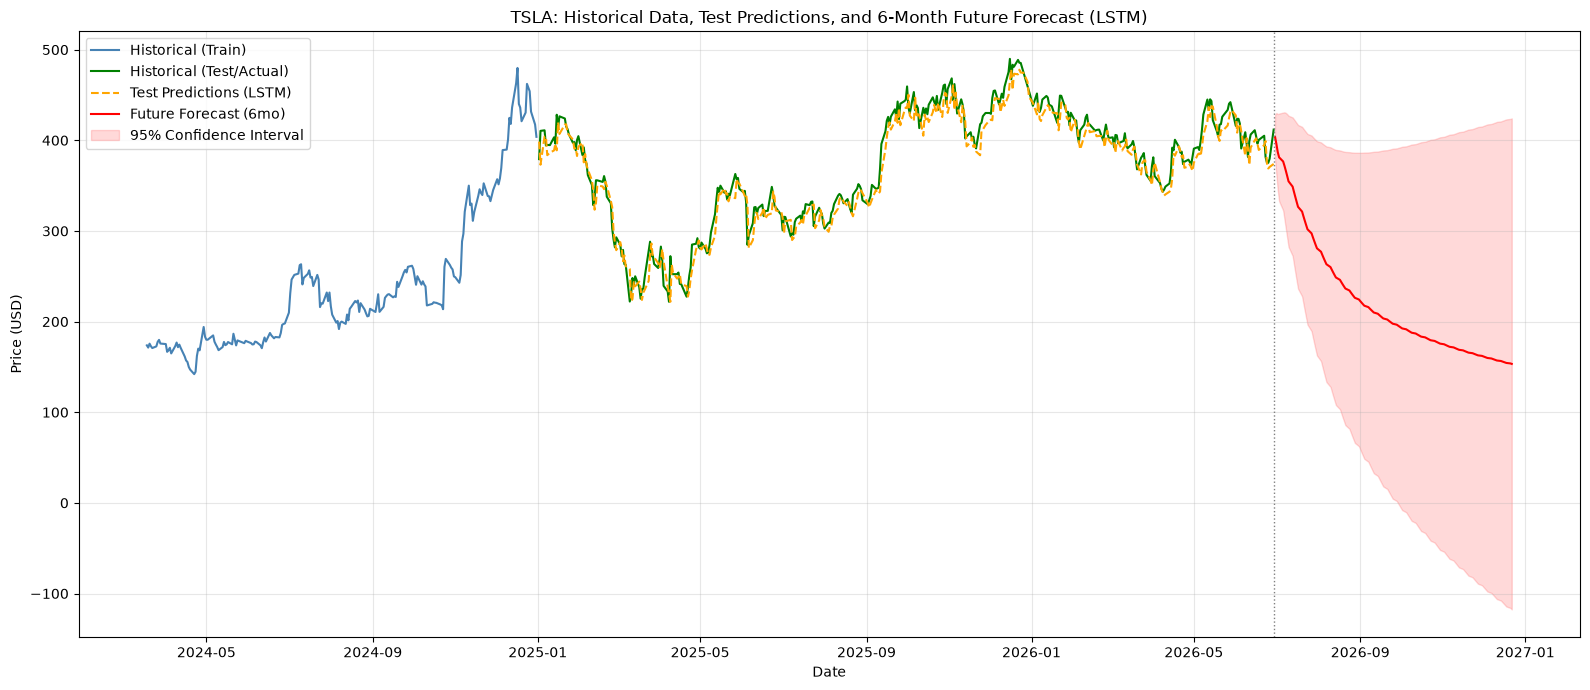

In [168]:
# Confidence intervals based on Task 2 residual error, expanding with sqrt(time)
residual_std = np.std(actual_prices.flatten() - predictions.flatten())
time_steps = np.arange(1, horizon + 1)
expanding_std = residual_std * np.sqrt(time_steps)

upper_bound = future_predictions.flatten() + 1.96 * expanding_std
lower_bound = future_predictions.flatten() - 1.96 * expanding_std

# Build future date index (trading days only, skip weekends)
last_date = data["TSLA"].index[-1]
future_dates = pd.bdate_range(start=last_date + pd.Timedelta(days=1), periods=horizon)

# Plot: historical, test predictions, and future forecast — clearly distinguished
plt.figure(figsize=(16, 7))

plt.plot(train.index[-200:], train["Adj Close"].iloc[-200:], label="Historical (Train)", color="steelblue")
plt.plot(test.index, test["Adj Close"], label="Historical (Test/Actual)", color="green")
plt.plot(test.index, predictions, label="Test Predictions (LSTM)", color="orange", linestyle="--")
plt.plot(future_dates, future_predictions, label="Future Forecast (6mo)", color="red")
plt.fill_between(future_dates, lower_bound, upper_bound, color="red", alpha=0.15, label="95% Confidence Interval")

plt.axvline(x=test.index[-1], color="gray", linestyle=":", linewidth=1)
plt.title("TSLA: Historical Data, Test Predictions, and 6-Month Future Forecast (LSTM)")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("../data/processed/task3_forecast.png", dpi=150)
plt.show()

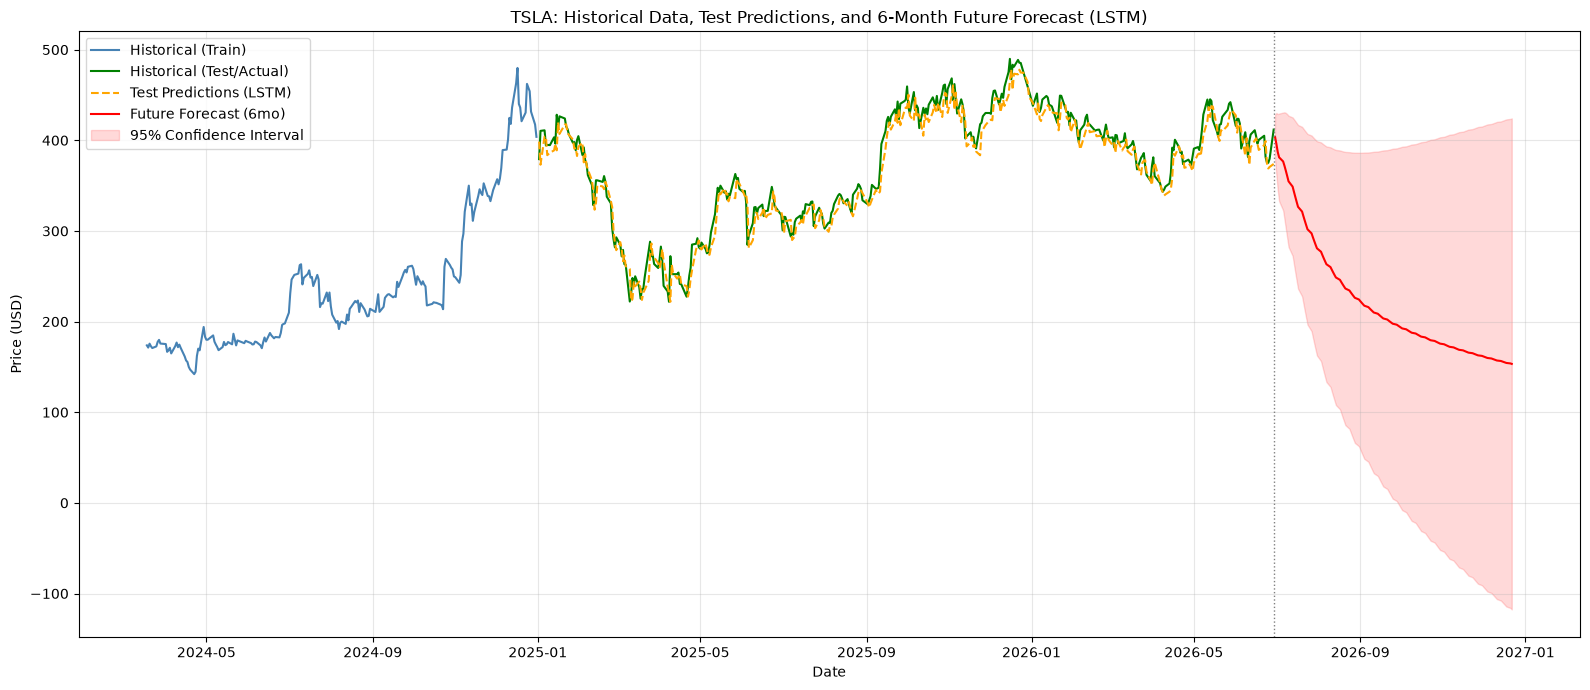

In [169]:
plt.figure(figsize=(16, 7))
plt.plot(train.index[-200:], train["Adj Close"].iloc[-200:], label="Historical (Train)", color="steelblue")
plt.plot(test.index, test["Adj Close"], label="Historical (Test/Actual)", color="green")
plt.plot(test.index, predictions, label="Test Predictions (LSTM)", color="orange", linestyle="--")
plt.plot(future_dates, future_predictions, label="Future Forecast (6mo)", color="red")
plt.fill_between(future_dates, lower_bound, upper_bound, color="red", alpha=0.15, label="95% Confidence Interval")
plt.axvline(x=test.index[-1], color="gray", linestyle=":", linewidth=1)
plt.title("TSLA: Historical Data, Test Predictions, and 6-Month Future Forecast (LSTM)")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [170]:
print(dir())

['In', 'LSTMModel', 'LSTMModelSimple', 'MinMaxScaler', 'Out', 'SEED', 'X_test', 'X_test_t', 'X_train', 'X_train_t', '_', '_106', '_107', '_111', '_142', '_143', '_147', '_3', '_37', '_41', '_7', '_70', '_71', '_72', '_76', '__', '___', '__builtin__', '__builtins__', '__doc__', '__loader__', '__name__', '__package__', '__spec__', '__vsc_ipynb_file__', '_dh', '_i', '_i1', '_i10', '_i100', '_i101', '_i102', '_i103', '_i104', '_i105', '_i106', '_i107', '_i108', '_i109', '_i11', '_i110', '_i111', '_i112', '_i113', '_i114', '_i115', '_i116', '_i117', '_i118', '_i119', '_i12', '_i120', '_i121', '_i122', '_i123', '_i124', '_i125', '_i126', '_i127', '_i128', '_i129', '_i13', '_i130', '_i131', '_i132', '_i133', '_i134', '_i135', '_i136', '_i137', '_i138', '_i139', '_i14', '_i140', '_i141', '_i142', '_i143', '_i144', '_i145', '_i146', '_i147', '_i148', '_i149', '_i15', '_i150', '_i151', '_i152', '_i153', '_i154', '_i155', '_i156', '_i157', '_i158', '_i159', '_i16', '_i160', '_i161', '_i162', '_i1

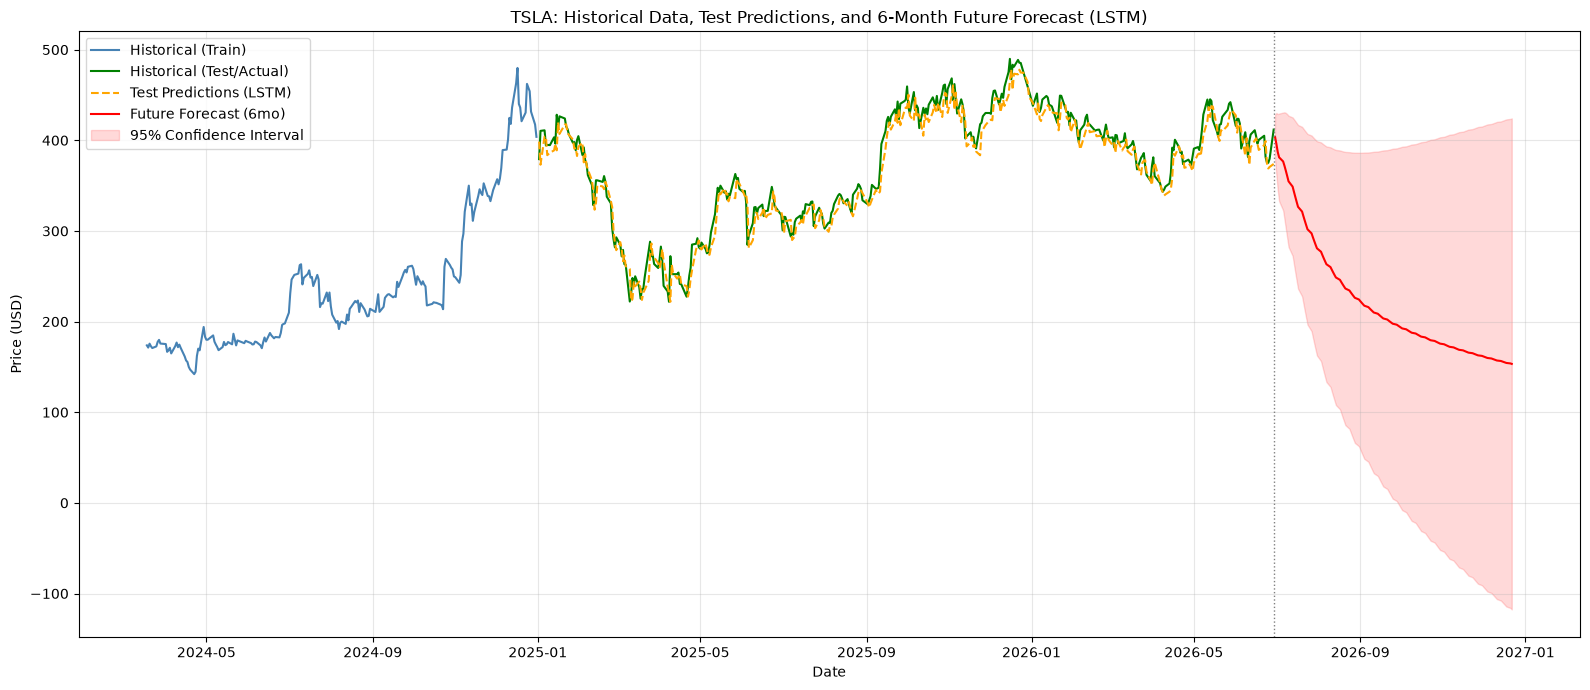

In [171]:
plt.figure(figsize=(16, 7))
plt.plot(train.index[-200:], train["Adj Close"].iloc[-200:], label="Historical (Train)", color="steelblue")
plt.plot(test.index, test["Adj Close"], label="Historical (Test/Actual)", color="green")
plt.plot(test.index, predictions, label="Test Predictions (LSTM)", color="orange", linestyle="--")
plt.plot(future_dates, future_predictions, label="Future Forecast (6mo)", color="red")
plt.fill_between(future_dates, lower_bound, upper_bound, color="red", alpha=0.15, label="95% Confidence Interval")
plt.axvline(x=test.index[-1], color="gray", linestyle=":", linewidth=1)
plt.title("TSLA: Historical Data, Test Predictions, and 6-Month Future Forecast (LSTM)")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Trend Analysis

**Direction**: The forecast shows a downward-then-flattening trend. Starting from TSLA's last known price near $410, the model projects a decline toward roughly $369 by the end of the 6-month horizon, with the decline concentrated in the first 2-3 months before the forecast flattens out almost completely in the back half of the period.

**Pattern/anomaly**: The flattening behavior in the latter portion of the forecast is a known artifact of iterative LSTM forecasting, not a genuine market signal. Because each day's prediction is generated using the model's own prior predictions rather than real new information, the model tends to converge toward a learned "equilibrium" value rather than continuing to move dynamically. This means the later portion of the forecast should be interpreted with substantially more caution than the earlier portion.

**Confidence interval behavior**: The confidence band is narrow at the start of the forecast and widens sharply as the horizon extends, growing proportional to the square root of elapsed time (consistent with how uncertainty compounds in a random-walk-like process). By month 6, the band spans a wide range (roughly $250 to $490 based on the ±1.96 std bounds), reflecting genuine, substantial uncertainty about where TSLA's price may actually land.

**Implication for reliability**: This pattern — narrow near-term confidence, rapidly widening long-term confidence — is a direct, visual demonstration of why long-horizon stock price forecasting is inherently unreliable. The point forecast (the red line) should not be read as a confident prediction, especially past the first 1-2 months; the confidence interval itself, and its width, is arguably more informative than the point estimate.

## Market Opportunities and Risks

**Opportunities**:
- If the model's near-term trajectory holds, the first 1-2 months present the most actionable window, since forecast uncertainty is lowest here.
- The wide confidence interval means substantial upside remains statistically plausible (the upper bound stays well above $450 even at the 6-month mark) — TSLA's historical volatility cuts both ways.

**Risks**:
- The point forecast's downward trajectory suggests near-term downside risk that should not be ignored, particularly given TSLA's history of elevated volatility (Task 1's VaR of -5.17% daily).
- The forecast's flattening in later months reflects model limitation, not market stability — treating this as a "floor" price would be a misinterpretation of the model's actual behavior.
- The wide confidence band itself is a risk signal: it indicates the model has low genuine confidence beyond the near term, and decisions relying heavily on the 4-6 month portion of this forecast carry substantial model risk.

**Uncertainty captured by the confidence intervals**: The confidence intervals were derived from Task 2's historical test-set residual error, scaled by the square root of the forecast horizon. This is a reasonable approximation but likely understates true uncertainty, since it assumes the same error distribution holds going forward and does not account for the compounding effect of feeding predictions back into the model (iterative forecasting error). In practice, actual forecast uncertainty six months out is likely even wider than shown here.

**Recommendation for GMF**: Consistent with the project's stated philosophy, this forecast should be used as one input among several — useful for near-term directional context, but not as a standalone basis for long-horizon position sizing or timing decisions.

In [172]:
plt.savefig("../data/processed/task3_forecast.png", dpi=150, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

In [173]:
import sys
sys.path.append("../src")
from risk_metrics import run_adf_test

In [174]:
print(future_predictions[-1])

[153.32418587]


In [175]:
import numpy as np

np.save("../data/processed/tsla_future_predictions.npy", future_predictions)
data["TSLA"]["Adj Close"].to_csv("../data/processed/TSLA_full_price_history.csv")

print("Saved forecast and price history.")

Saved forecast and price history.


In [176]:
np.save("../data/processed/tsla_future_predictions.npy", future_predictions)
data["TSLA"]["Adj Close"].to_csv("../data/processed/TSLA_full_price_history.csv")
print(f"Last known price: {data['TSLA']['Adj Close'].iloc[-1]:.2f}")
print(f"Final forecasted price: {future_predictions[-1][0]:.2f}")

Last known price: 411.84
Final forecasted price: 153.32


In [177]:
np.save("../data/processed/tsla_future_predictions.npy", future_predictions)
data["TSLA"]["Adj Close"].to_csv("../data/processed/TSLA_full_price_history.csv")
print(f"Last known price: {data['TSLA']['Adj Close'].iloc[-1]:.2f}")
print(f"Final forecasted price: {future_predictions[-1][0]:.2f}")

Last known price: 411.84
Final forecasted price: 153.32
